In [1]:
%pip install opencv-python scipy

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
    --------------------------------------- 0.8/40.2 MB 4.5 MB/s eta 0:00:09
   - -------------------------------------- 1.8/40.2 MB 4.6 MB/s eta 0:00:09
   -- ------------------------------------- 2.9/40.2 MB 4.6 MB/s eta 0:00:09
   --- ------------------------------------ 3.7/40.2 MB 4.6 MB/s eta 0:00:08
   ---- ----------------------------------- 4.7/40.2 MB 4.6 MB/s eta 0:00:08
   ----- ---------------------------------- 5.5/40.2 MB 4.6 MB/s eta 0:00:08
   ------ --------------------------------- 6.6/40.2 MB 4.6 MB/s eta 0:00:08
   ------- -------------------------------- 7.6/40.2 MB 4.6 MB/s eta 0:00:08
   -------- ------------------------------- 8.4/40.2 MB 4.6 MB/s eta 0:00:07
   --------- ------------------------------ 9.4/40.2 MB 4.6 MB/s eta 0:00:07
   ---------- ----------------------------- 10.2/40.2 MB 4.6 MB/s eta 0:00:07
   ----------- ---------------------------- 11.3/40.2 MB 4.6 MB/s eta 0:00:07
   -

Step 1 — Define paths + build an ID→mask lookup

Utilising pectoral masks for MLO images, taken from the following repo: 

https://github.com/Parvaneh-Aliniya/pectoral_muscle_groundtruth_segmentation

1. Paper converted the DICOM to PNG images first - which we have not done 
2. Have not set the background to NaN
3. They used "histogram-based contrast adjustment technique", while we used CLAHE


DICOMs: 410
JSON masks: 202
DICOMs with a matching JSON mask: 202

Example:
DICOM: 50996709_330e5fe16929eed4_MG_R_ML_ANON.dcm
MASK : 50996709_330e5fe16929eed4_MG_R_ML_ANON.json
Image shape: (4084, 3328) | Mask sum: 315380


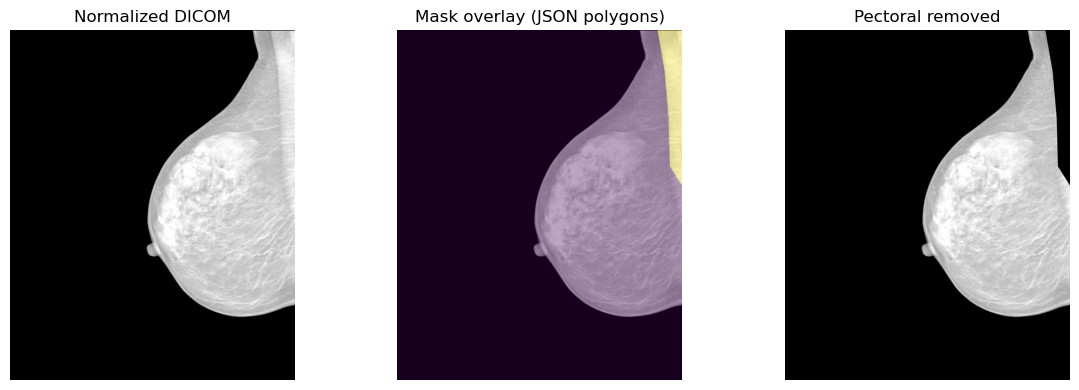

In [10]:
from pathlib import Path
import json
import random

import numpy as np
import pydicom
import matplotlib.pyplot as plt
import cv2
from pydicom.pixel_data_handlers.util import apply_voi_lut

# ---- EDIT THESE PATHS ----
DICOM_DIR = Path("data/raw/inbreast/ALL-IMGS")
MASK_DIR  = Path("data/raw/muscle_masks_for_raw_data")  # where you copied the JSON masks
# -------------------------

# 1) Collect files
dicoms = sorted(DICOM_DIR.glob("*.dcm"))

# ignore Windows "Zone.Identifier" garbage if present
json_masks = [p for p in MASK_DIR.rglob("*.json") if "Zone.Identifier" not in p.name]

print("DICOMs:", len(dicoms))
print("JSON masks:", len(json_masks))

mask_by_stem = {p.stem: p for p in json_masks}

matched = [p for p in dicoms if p.stem in mask_by_stem]
print("DICOMs with a matching JSON mask:", len(matched))

if len(matched) == 0:
    # helpful debugging: show example stems
    print("\nExample DICOM stems:", [p.stem for p in dicoms[:5]])
    print("Example MASK stems:", [p.stem for p in json_masks[:5]])
    raise RuntimeError("No matches found. Likely different naming scheme between your DICOMs and the mask JSONs.")

# 2) Helpers: load/normalize DICOM + convert LabelMe JSON polygons -> binary mask
def load_dicom_norm(path: Path) -> np.ndarray:
    ds = pydicom.dcmread(str(path))
    img = ds.pixel_array.astype(np.float32)

    try:
        img = apply_voi_lut(img, ds).astype(np.float32)
    except Exception:
        pass

    if getattr(ds, "PhotometricInterpretation", "") == "MONOCHROME1":
        img = img.max() - img

    lo, hi = np.percentile(img, (1, 99))
    img = np.clip(img, lo, hi)
    img = (img - lo) / (hi - lo + 1e-8)
    return img

def labelme_json_to_mask(json_path: Path, shape_hw: tuple[int,int]) -> np.ndarray:
    """
    Makes a binary mask from LabelMe-like JSON.
    We fill ALL polygons found in 'shapes'.
    """
    H, W = shape_hw
    mask = np.zeros((H, W), dtype=np.uint8)

    with open(json_path, "r", encoding="utf-8") as f:
        ann = json.load(f)

    shapes = ann.get("shapes", [])
    for s in shapes:
        pts = np.array(s.get("points", []), dtype=np.float32)
        if pts.size == 0:
            continue
        pts = np.round(pts).astype(np.int32)
        pts[:, 0] = np.clip(pts[:, 0], 0, W - 1)
        pts[:, 1] = np.clip(pts[:, 1], 0, H - 1)
        cv2.fillPoly(mask, [pts], 1)

    return mask

# 3) Pick a random matched image (prefer MLO/ML if available)
def looks_like_mlo(name: str) -> bool:
    u = name.upper()
    return ("_MLO_" in u) or ("_ML_" in u)  # your masks use "_ML_" in the example

mlo_matched = [p for p in matched if looks_like_mlo(p.name)]
dicom_path = random.choice(mlo_matched if mlo_matched else matched)
mask_path = mask_by_stem[dicom_path.stem]

img = load_dicom_norm(dicom_path)
mask = labelme_json_to_mask(mask_path, img.shape)

# 4) Apply mask (remove pectoral)
img_no_pect = img.copy()
img_no_pect[mask == 1] = 0.0

print("\nExample:")
print("DICOM:", dicom_path.name)
print("MASK :", mask_path.name)
print("Image shape:", img.shape, "| Mask sum:", int(mask.sum()))

# 5) Show side-by-side
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap="gray")
plt.title("Normalized DICOM")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(img, cmap="gray")
plt.imshow(mask, alpha=0.35)
plt.title("Mask overlay (JSON polygons)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(img_no_pect, cmap="gray")
plt.title("Pectoral removed")
plt.axis("off")

plt.tight_layout()
plt.show()

Cell 1 — Build mapping + dataset coverage report

In [12]:
from pathlib import Path
import re
import pandas as pd

DICOM_DIR = Path("data/raw/inbreast/ALL-IMGS")
MASK_DIR  = Path("data/raw/muscle_masks_for_raw_data")  # where your JSONs live

dicoms = sorted(DICOM_DIR.glob("*.dcm"))
json_masks = [p for p in MASK_DIR.rglob("*.json") if "Zone.Identifier" not in p.name]

print("DICOMs:", len(dicoms))
print("JSON masks:", len(json_masks))

mask_by_stem = {p.stem: p for p in json_masks}

rows = []
for d in dicoms:
    u = d.name.upper()
    view = "MLO" if "_MLO_" in u else ("CC" if "_CC_" in u else ("ML" if "_ML_" in u else "UNK"))
    lat  = "R" if "_R_" in u else ("L" if "_L_" in u else "UNK")
    rows.append({
        "stem": d.stem,
        "dicom": str(d),
        "view": view,
        "laterality": lat,
        "has_pect_json": d.stem in mask_by_stem,
        "pect_json": str(mask_by_stem[d.stem]) if d.stem in mask_by_stem else None,
    })

cov = pd.DataFrame(rows)
display(cov["has_pect_json"].value_counts())
display(cov.groupby(["view","has_pect_json"]).size().unstack(fill_value=0))

DICOMs: 410
JSON masks: 202


has_pect_json
False    208
True     202
Name: count, dtype: int64

has_pect_json,False,True
view,,
CC,202,1
ML,5,201
UNK,1,0


Cell 2 — Core helpers (DICOM normalize + JSON polygons → mask)

In [13]:
import json
import numpy as np
import pydicom
import matplotlib.pyplot as plt
import cv2
from pydicom.pixel_data_handlers.util import apply_voi_lut

def load_dicom_norm(path: Path) -> np.ndarray:
    ds = pydicom.dcmread(str(path))
    img = ds.pixel_array.astype(np.float32)

    try:
        img = apply_voi_lut(img, ds).astype(np.float32)
    except Exception:
        pass

    if getattr(ds, "PhotometricInterpretation", "") == "MONOCHROME1":
        img = img.max() - img

    lo, hi = np.percentile(img, (1, 99))
    img = np.clip(img, lo, hi)
    img = (img - lo) / (hi - lo + 1e-8)
    return img

def labelme_json_to_mask(json_path: Path, shape_hw: tuple[int,int]) -> np.ndarray:
    """Fill all polygons in LabelMe-style JSON into a binary mask."""
    H, W = shape_hw
    mask = np.zeros((H, W), dtype=np.uint8)

    with open(json_path, "r", encoding="utf-8") as f:
        ann = json.load(f)

    shapes = ann.get("shapes", [])
    for s in shapes:
        pts = np.array(s.get("points", []), dtype=np.float32)
        if pts.size == 0:
            continue
        pts = np.round(pts).astype(np.int32)
        pts[:, 0] = np.clip(pts[:, 0], 0, W - 1)
        pts[:, 1] = np.clip(pts[:, 1], 0, H - 1)
        cv2.fillPoly(mask, [pts], 1)

    return mask